# Part 1: Prepare the stock-return data

## Step 1: Read the ticker file


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import gurobipy as gp
from gurobipy import GRB
from IPython.display import Markdown, display

#Please update the file name here
TICKER_FILE = "TickerFile.csv"

ticker_file = pd.read_csv(TICKER_FILE)

# # Model settings specified in the assignment.
BETA_BASELINE = 0.95
REQUIRED_DAILY_RETURN = 0.0002  # 0.02% written as a decimal
WEIGHT_TOLERANCE = 1e-6
BENCHMARK_TICKER = "^GSPC"      # Yahoo Finance symbol for the S&P 500


TRAIN_START = "2025-01-01"
TRAIN_DOWNLOAD_END = "2026-01-01"  # exclusive: includes through 2025-12-31
TEST_START = "2026-01-01"
TEST_DOWNLOAD_END = "2026-09-15"   # exclusive: includes through 2026-09-14

In [34]:
# Validate and clean the symbols supplied in the CSV.
if "Ticker" not in ticker_file.columns:
    raise ValueError("The input CSV must contain a column named 'Ticker'.")

tickers = (
    ticker_file["Ticker"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(".", "-", regex=False)  # Yahoo uses BRK-B instead of BRK.B
    .drop_duplicates()
    .tolist()
)

if not tickers:
    raise ValueError("The ticker file does not contain any usable symbols.")

# Show a compact summary.
print(f"Number of supplied stocks: {len(tickers)}")
print("First 10 ticker symbols:", tickers[:10])


Number of supplied stocks: 4
First 10 ticker symbols: ['AAPL', 'CVX', 'XOM', 'GOOG']


## Step 2: Download adjusted closing prices

We use **adjusted closing prices** because they account for stock splits and dividends. We download 2025 for portfolio construction and 2026 through September 14 for out-of-sample evaluation.

Yahoo Finance treats the `end` date as exclusive. Therefore:

- `end="2026-01-01"` includes December 31, 2025.
- `end="2026-09-15"` includes September 14, 2026.


In [35]:
# Download adjusted closing prices for the requested date range.
# Keeping this step inside a function lets the same logic be reused for 2025
# and 2026 without duplicating the download code.
def download_adjusted_close(symbols, start_date, end_date):
    '''Download adjusted closing prices and preserve the supplied ticker order.'''
    raw_data = yf.download(
        tickers=symbols,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=False,
        group_by="column",
        multi_level_index=True,
        progress=False,
        threads=True
    )

    if raw_data.empty:
        raise ValueError(f"No price data was downloaded for {start_date} to {end_date}.")

    # With multi_level_index=True, the first column level contains price fields.
    if "Adj Close" not in raw_data.columns.get_level_values(0):
        raise ValueError("Yahoo Finance did not return an 'Adj Close' field.")

    adjusted_close = raw_data["Adj Close"].copy()

    # yfinance may return a Series when only one ticker is supplied.
    if isinstance(adjusted_close, pd.Series):
        adjusted_close = adjusted_close.to_frame(name=symbols[0])

    return adjusted_close.reindex(columns=symbols)


prices_2025_raw = download_adjusted_close(
    tickers,
    start_date=TRAIN_START,
    end_date=TRAIN_DOWNLOAD_END
)

prices_2026_raw = download_adjusted_close(
    tickers,
    start_date=TEST_START,
    end_date=TEST_DOWNLOAD_END
)

print("2025 price shape:", prices_2025_raw.shape)
print("2025 date range:", prices_2025_raw.index.min(), "to", prices_2025_raw.index.max())
print("2026 price shape:", prices_2026_raw.shape)
print("2026 date range:", prices_2026_raw.index.min(), "to", prices_2026_raw.index.max())


2025 price shape: (250, 4)
2025 date range: 2025-01-02 00:00:00 to 2025-12-31 00:00:00
2026 price shape: (175, 4)
2026 date range: 2026-01-02 00:00:00 to 2026-09-14 00:00:00


## Step 3: Clean the price data

Gurobi needs a complete rectangular return matrix. A stock must have usable adjusted prices in both periods so that its 2025 weight can be evaluated in 2026. The following cell removes stocks with missing prices and reports exactly what was removed.


In [36]:
# Keep only stocks with complete price histories in both periods.
complete_2025 = ~prices_2025_raw.isna().any(axis=0)
complete_2026 = ~prices_2026_raw.isna().any(axis=0)

eligible_tickers = [
    ticker for ticker in tickers
    if complete_2025.get(ticker, False) and complete_2026.get(ticker, False)
]
removed_tickers = [ticker for ticker in tickers if ticker not in eligible_tickers]

if not eligible_tickers:
    raise ValueError("No stocks have complete price histories in both periods.")

prices_2025 = prices_2025_raw[eligible_tickers].copy()
prices_2026 = prices_2026_raw[eligible_tickers].copy()

print(f"Stocks retained: {len(eligible_tickers)}")
print("Stocks removed for incomplete prices:", removed_tickers or "None")
print("Remaining missing prices in 2025:", int(prices_2025.isna().sum().sum()))
print("Remaining missing prices in 2026:", int(prices_2026.isna().sum().sum()))


Stocks retained: 4
Stocks removed for incomplete prices: None
Remaining missing prices in 2025: 0
Remaining missing prices in 2026: 0


## Step 4: Calculate daily returns

This is where we calculate the **daily change** required by Part 1.

For stock $j$ on day $k$:

$$y_{kj}=\frac{P_{kj}}{P_{k-1,j}}-1.$$

For example, if the adjusted price increases from $100 to $102, the daily return is

$$\frac{102}{100}-1=0.02=2\%.$$

For the first 2026 trading day, we use the final 2025 price as the previous price. Otherwise, that first 2026 return would incorrectly be discarded.


In [37]:
# Convert prices into simple daily percentage returns.
# The first observation is dropped because there is no earlier price from which
# a return can be calculated.
# Calculate 2025 daily returns. The first price row has no prior price,
# so it is removed after pct_change().
returns_2025 = (
    prices_2025
    .pct_change(fill_method=None)
    .iloc[1:]
)

# Include the final 2025 price when calculating the first 2026 return.
prices_2026_with_prior = pd.concat([
    prices_2025.tail(1),
    prices_2026
])

# The last 2025 price provides the prior observation needed for the first 2026 trading-day return.
returns_2026 = (
    prices_2026_with_prior
    .pct_change(fill_method=None)
    .iloc[1:]
)

# Validate the return matrices before optimization.
for label, data in [("2025", returns_2025), ("2026", returns_2026)]:
    if data.empty:
        raise ValueError(f"The {label} return dataset is empty.")
    if data.isna().any().any():
        raise ValueError(f"The {label} return dataset contains missing values.")
    if not np.isfinite(data.to_numpy(dtype=float)).all():
        raise ValueError(f"The {label} return dataset contains infinite values.")
    if data.index.duplicated().any():
        raise ValueError(f"The {label} return dataset contains duplicate dates.")

if not returns_2025.columns.equals(returns_2026.columns):
    raise ValueError("The 2025 and 2026 stock columns do not match.")

print(f"2025 return matrix: {returns_2025.shape[0]} days x {returns_2025.shape[1]} stocks")
print(f"2026 return matrix: {returns_2026.shape[0]} days x {returns_2026.shape[1]} stocks")
print("Return-data validation passed.")
display(returns_2025.head())


2025 return matrix: 249 days x 4 stocks
2026 return matrix: 175 days x 4 stocks
Return-data validation passed.


Ticker,AAPL,CVX,XOM,GOOG
Date,,,,
2025-01-03,-0.002009,0.007770,0.005125,0.013114
2025-01-06,0.006739,-0.003990,-0.001113,0.025009
2025-01-07,-0.011388,0.015822,0.009374,-0.006314
2025-01-08,0.002023,0.004746,-0.016736,-0.006710
2025-01-10,-0.024104,0.018895,-0.003647,-0.011362


# Part 2: Construct and evaluate the 95%-CVaR portfolio

## Step 5: Understand the Gurobi model

Let $x_j$ be the weight assigned to stock $j$. On historical day $k$, the portfolio return is

$$x^Ty_k=\sum_jx_jy_{kj},$$

and the portfolio loss is $-x^Ty_k$.

With $n$ stocks and $q$ historical days, Gurobi chooses:

- $n$ weights $x_1,\ldots,x_n$;
- one variable $\alpha$, representing the VaR loss cutoff; and
- $q$ auxiliary variables $u_1,\ldots,u_q$, measuring each day's loss beyond $\alpha$.

The model minimizes

$$\alpha+\frac{1}{(1-\beta)q}\sum_{k=1}^{q}u_k$$

subject to

$$u_k\ge -x^Ty_k-\alpha,\quad u_k\ge0,$$

$$\sum_jx_j=1,\quad x_j\ge0,$$

and

$$\bar y^Tx\ge0.0002.$$

At $\beta=0.95$, the model focuses on approximately the worst 5% of historical daily losses.


In [38]:
# For a fixed portfolio, convert returns to losses and evaluate the sample
# CVaR using the Rockafellar-Uryasev representation from the project.
# The second function formulates the corresponding linear program in Gurobi.
def calculate_fixed_portfolio_cvar(portfolio_returns, beta):
    '''Calculate VaR and CVaR for a fixed sequence of portfolio returns.'''
    if not 0.0 < beta < 1.0:
        raise ValueError("beta must be strictly between 0 and 1.")

    portfolio_returns = np.asarray(portfolio_returns, dtype=float).reshape(-1)

    # CVaR is expressed in terms of losses, so a negative return becomes a positive loss.
    losses = -portfolio_returns

    # The CVaR objective changes slope only at observed losses, so testing
    # every observed loss is sufficient when the portfolio weights are fixed.
    # For fixed weights, an optimal alpha occurs at an observed loss value, so these are the relevant candidates.
    candidate_alphas = np.unique(losses)
    excess_losses = np.maximum(
        losses[:, None] - candidate_alphas[None, :],
        0.0
    )
    candidate_cvars = (
        candidate_alphas
        + excess_losses.sum(axis=0)
        / ((1.0 - beta) * len(losses))
    )

    best_position = int(np.argmin(candidate_cvars))
    return (
        float(candidate_alphas[best_position]),
        float(candidate_cvars[best_position])
    )


def solve_cvar_portfolio(return_data, beta, required_return):
    '''Use Gurobi to find the long-only minimum-CVaR portfolio.'''
    if not 0.0 < beta < 1.0:
        raise ValueError("beta must be strictly between 0 and 1.")

    Y = return_data.to_numpy(dtype=float)
    q, n = Y.shape
    # Compute each stock's historical mean daily return for the required-return constraint.
    mean_stock_returns = Y.mean(axis=0)

    # A long-only weighted average cannot exceed the largest stock mean.
    if mean_stock_returns.max() < required_return:
        raise ValueError("The required return is infeasible for these stocks.")

    model = gp.Model(f"cvar_beta_{beta:.2f}")
    model.Params.OutputFlag = 0

    # Decision variables
    # x_j: portfolio weight for stock j. lb=0 enforces the long-only requirement.
    weights = model.addMVar(n, lb=0.0, name="weight")
    # alpha is the VaR threshold in the CVaR formulation and is allowed to take either sign.
    alpha = model.addVar(lb=-GRB.INFINITY, name="alpha")
    # u_k: excess loss above alpha for each historical day; nonnegative by construction.
    excess_loss = model.addMVar(q, lb=0.0, name="excess_loss")

    # Objective: minimize the sample estimate of beta-CVaR.
    model.setObjective(
        alpha + excess_loss.sum() / ((1.0 - beta) * q),
        GRB.MINIMIZE
    )

    # Portfolio constraints
    model.addConstr(weights.sum() == 1.0, name="fully_invested")
    model.addConstr(
        mean_stock_returns @ weights >= required_return,
        name="required_mean_return"
    )

    # One excess-loss constraint for every historical day.
    model.addConstr(
        excess_loss >= -(Y @ weights) - alpha,
        name="daily_excess_loss"
    )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"Gurobi did not find an optimal solution; status={model.Status}."
        )

    optimized_weights = weights.X.copy()
    portfolio_returns = Y @ optimized_weights

    return {
        "Beta": beta,
        "Weights": optimized_weights,
        "VaR": float(alpha.X),
        "CVaR": float(model.ObjVal),
        "Mean_Return": float(mean_stock_returns @ optimized_weights),
        "Portfolio_Returns": portfolio_returns,
        "Days": q,
        "Stocks": n,
        "Decision_Variables": n + 1 + q
    }


## Step 6: Optimize the portfolio using 2025 returns

This is the **in-sample** construction step. Gurobi sees the 2025 return scenarios and chooses one weight for every eligible stock. It does not use 2026 information when selecting the weights.


In [39]:
# Solve the required baseline model: beta = 0.95 and the minimum daily
# expected-return constraint specified in the assignment.
# The checks below confirm that the returned solution satisfies the key
# portfolio constraints and that the reported CVaR is reproduced independently.
baseline_result = solve_cvar_portfolio(
    return_data=returns_2025,
    beta=BETA_BASELINE,
    required_return=REQUIRED_DAILY_RETURN
)

baseline_weights = baseline_result["Weights"]

# Independently recalculate CVaR and validate the Gurobi solution.
# This helps catch modeling or implementation errors that might otherwise be hidden by the solver output.
direct_var_2025, direct_cvar_2025 = calculate_fixed_portfolio_cvar(
    baseline_result["Portfolio_Returns"],
    BETA_BASELINE
)

assert np.isclose(baseline_weights.sum(), 1.0, atol=1e-7)
assert baseline_weights.min() >= -1e-8
assert baseline_result["Mean_Return"] >= REQUIRED_DAILY_RETURN - 1e-8
assert np.isclose(direct_cvar_2025, baseline_result["CVaR"], atol=1e-7)

print("Gurobi found an optimal 2025 portfolio.")
print("Number of weights (n):", baseline_result["Stocks"])
print("Number of historical days (q):", baseline_result["Days"])
print("Total variables (n + 1 + q):", baseline_result["Decision_Variables"])
print(f"2025 VaR: {baseline_result['VaR']:.4%}")
print(f"2025 CVaR: {baseline_result['CVaR']:.4%}")
print(f"Mean daily return: {baseline_result['Mean_Return']:.4%}")
print(f"Sum of weights: {baseline_weights.sum():.8f}")

Gurobi found an optimal 2025 portfolio.
Number of weights (n): 4
Number of historical days (q): 249
Total variables (n + 1 + q): 254
2025 VaR: 1.8604%
2025 CVaR: 2.9135%
Mean daily return: 0.1195%
Sum of weights: 1.00000000


Stocks receiving a meaningful allocation: 3


,Ticker,Weight,Weight_Percent
0,XOM,0.600591,60.059060
1,GOOG,0.321682,32.168247
2,AAPL,0.077727,7.772693


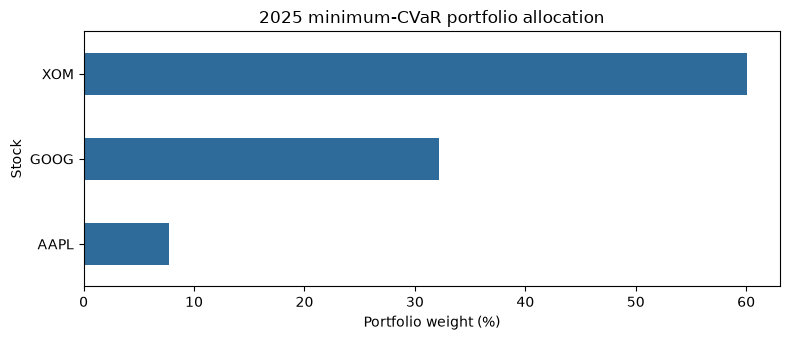

In [40]:
# Match every optimized weight with its ticker.
baseline_allocation = pd.DataFrame({
    "Ticker": returns_2025.columns,
    "Weight": baseline_weights
})
baseline_allocation["Weight_Percent"] = 100 * baseline_allocation["Weight"]

active_baseline_allocation = (
    baseline_allocation.loc[
        baseline_allocation["Weight"] > WEIGHT_TOLERANCE
    ]
    .sort_values("Weight", ascending=False)
    .reset_index(drop=True)
)

print("Stocks receiving a meaningful allocation:", len(active_baseline_allocation))
display(active_baseline_allocation)

# Plot the allocation for use in the final report.
plot_allocation = active_baseline_allocation.sort_values("Weight_Percent")
ax = plot_allocation.plot.barh(
    x="Ticker",
    y="Weight_Percent",
    legend=False,
    figsize=(8, max(3.5, 0.35 * len(plot_allocation))),
    color="#2F6B9A"
)
ax.set_title("2025 minimum-CVaR portfolio allocation")
ax.set_xlabel("Portfolio weight (%)")
ax.set_ylabel("Stock")
plt.tight_layout()
plt.show()


## Step 7: Evaluate the unchanged portfolio using 2026 returns

For Part 2(a), we freeze the weights selected from 2025. We then calculate the portfolio's return on every 2026 day:

$$\text{2026 portfolio returns}=Y_{2026}x_{2025}.$$

We do not let Gurobi choose new weights using 2026 data. This is what makes 2026 an **out-of-sample** evaluation.


In [41]:
# We keep the 2025 optimized weights fixed and evaluate them on 2026 returns.

portfolio_returns_2026 = (
    returns_2026.to_numpy(dtype=float) @ baseline_weights
)

var_2026, cvar_2026 = calculate_fixed_portfolio_cvar(
    portfolio_returns_2026,
    BETA_BASELINE
)

mean_return_2026 = float(portfolio_returns_2026.mean())

in_out_sample_comparison = pd.DataFrame({
    "Period": ["2025 In-Sample", "2026 Out-of-Sample"],
    "VaR": [baseline_result["VaR"], var_2026],
    "CVaR": [baseline_result["CVaR"], cvar_2026],
    "Mean_Daily_Return": [baseline_result["Mean_Return"], mean_return_2026]
})

in_out_sample_display = in_out_sample_comparison.copy()
for column in ["VaR", "CVaR", "Mean_Daily_Return"]:
    in_out_sample_display[column] = (
        in_out_sample_display[column].map(lambda value: f"{value:.4%}")
    )
display(in_out_sample_display)

cvar_change = cvar_2026 / baseline_result["CVaR"] - 1.0
change_word = "increased" if cvar_change >= 0 else "decreased"

display(Markdown(f'''
### Part 2(a) analysis

The fixed portfolio's daily 95%-CVaR **{change_word} by {abs(cvar_change):.1%}**,
from **{baseline_result['CVaR']:.4%}** in 2025 to **{cvar_2026:.4%}** in 2026.
The difference means that the tail-risk pattern estimated from 2025 did not
transfer perfectly to the later period. This is evidence consistent with
**non-stationarity**, meaning that returns and relationships between stocks can
change over time. It does not by itself prove overfitting. The portfolio should
be monitored, and later parts of the project should compare it with periodic
reoptimization after considering turnover and transaction costs. The 2026 sample
ends on **{returns_2026.index.max():%B %d, %Y}**, so it is not a full year.
'''))


,Period,VaR,CVaR,Mean_Daily_Return
0,2025 In-Sample,1.8604%,2.9135%,0.1195%
1,2026 Out-of-Sample,1.5304%,1.9894%,0.1600%



### Part 2(a) analysis

The fixed portfolio's daily 95%-CVaR **decreased by 31.7%**,
from **2.9135%** in 2025 to **1.9894%** in 2026.
The difference means that the tail-risk pattern estimated from 2025 did not
transfer perfectly to the later period. This is evidence consistent with
**non-stationarity**, meaning that returns and relationships between stocks can
change over time. It does not by itself prove overfitting. The portfolio should
be monitored, and later parts of the project should compare it with periodic
reoptimization after considering turnover and transaction costs. The 2026 sample
ends on **September 14, 2026**, so it is not a full year.


## Step 8: Compare the portfolio with the S&P 500

Part 2(b) asks whether the optimized portfolio protects against extreme losses better than simply holding the S&P 500. We download one continuous S&P 500 price series, calculate its daily returns, and align those returns with the same dates used for the stock portfolios.


,Period,Portfolio_VaR,Portfolio_CVaR,SP500_VaR,SP500_CVaR,CVaR_Reduction_vs_SP500
0,2025 In-Sample,1.8604%,2.9135%,1.6135%,2.7217%,-7.05%
1,2026 Out-of-Sample,1.5304%,1.9894%,1.5138%,1.7692%,-12.45%


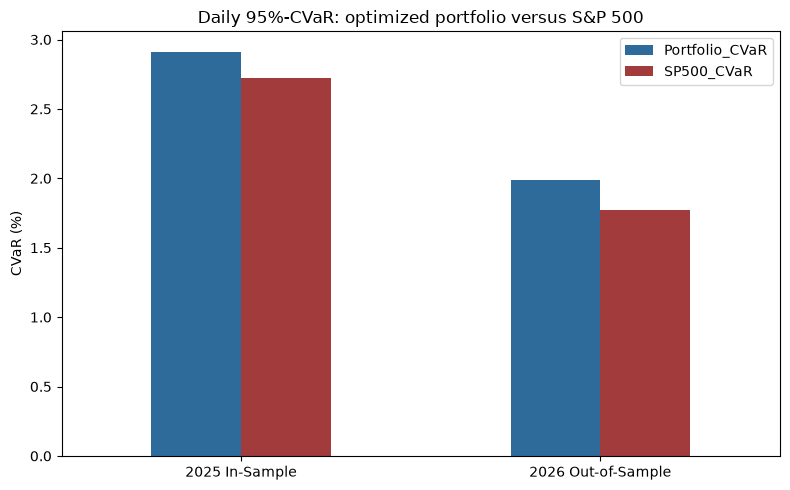


### Part 2(b) analysis

The optimized portfolio's daily 95%-CVaR was **2.9135%**
versus **2.7217%** for the S&P 500 in 2025. The portfolio CVaR
was therefore **7.0% higher** than the benchmark.
In the partial 2026 sample, the portfolio CVaR was **1.9894%** versus
**1.7692%** for the S&P 500, making it
**12.4% higher** than the benchmark.
The optimized portfolio did not outperform the benchmark on CVaR in either period. The limited supplied stock universe gave Gurobi fewer diversification choices than the full S&P 500 index. The change in relative performance also shows that risk
patterns were not constant across the two periods.


In [42]:
# Download S&P 500 adjusted closing prices to create a benchmark return series.
# The benchmark is evaluated over exactly the same trading dates as the
# optimized portfolio so the CVaR comparison is on a consistent basis.
# Start before the first stock-return date so the benchmark's first return
# also has a previous adjusted closing price.
benchmark_start = (
    min(returns_2025.index.min(), returns_2026.index.min())
    - pd.Timedelta(days=10)
)
benchmark_end = (
    max(returns_2025.index.max(), returns_2026.index.max())
    + pd.Timedelta(days=1)
)

benchmark_raw = yf.download(
    BENCHMARK_TICKER,
    start=benchmark_start.strftime("%Y-%m-%d"),
    end=benchmark_end.strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False,
    multi_level_index=False
)

if benchmark_raw.empty or "Adj Close" not in benchmark_raw.columns:
    raise ValueError("The S&P 500 adjusted closing prices were not downloaded.")

# Convert the benchmark's adjusted closing prices into daily returns.
benchmark_returns_all = (
    benchmark_raw["Adj Close"]
    .squeeze()
    .pct_change(fill_method=None)
    .dropna()
)

benchmark_returns_2025 = benchmark_returns_all.reindex(returns_2025.index)
benchmark_returns_2026 = benchmark_returns_all.reindex(returns_2026.index)

if benchmark_returns_2025.isna().any() or benchmark_returns_2026.isna().any():
    raise ValueError("Benchmark returns are missing on required trading dates.")

benchmark_var_2025, benchmark_cvar_2025 = calculate_fixed_portfolio_cvar(
    benchmark_returns_2025,
    BETA_BASELINE
)
benchmark_var_2026, benchmark_cvar_2026 = calculate_fixed_portfolio_cvar(
    benchmark_returns_2026,
    BETA_BASELINE
)

risk_comparison = pd.DataFrame({
    "Period": ["2025 In-Sample", "2026 Out-of-Sample"],
    "Portfolio_VaR": [baseline_result["VaR"], var_2026],
    "Portfolio_CVaR": [baseline_result["CVaR"], cvar_2026],
    "SP500_VaR": [benchmark_var_2025, benchmark_var_2026],
    "SP500_CVaR": [benchmark_cvar_2025, benchmark_cvar_2026]
})
risk_comparison["CVaR_Reduction_vs_SP500"] = (
    1.0 - risk_comparison["Portfolio_CVaR"] / risk_comparison["SP500_CVaR"]
)

risk_comparison_display = risk_comparison.copy()
for column in ["Portfolio_VaR", "Portfolio_CVaR", "SP500_VaR", "SP500_CVaR"]:
    risk_comparison_display[column] = (
        risk_comparison_display[column].map(lambda value: f"{value:.4%}")
    )
risk_comparison_display["CVaR_Reduction_vs_SP500"] = (
    risk_comparison_display["CVaR_Reduction_vs_SP500"]
    .map(lambda value: f"{value:.2%}")
)
display(risk_comparison_display)

# Plot CVaR rather than VaR because CVaR is the risk measure being minimized.
plot_data = risk_comparison.set_index("Period")[[
    "Portfolio_CVaR", "SP500_CVaR"
]] * 100
ax = plot_data.plot.bar(figsize=(8, 5), color=["#2F6B9A", "#A23B3B"])
ax.set_title("Daily 95%-CVaR: optimized portfolio versus S&P 500")
ax.set_ylabel("CVaR (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

reduction_2025 = risk_comparison.loc[0, "CVaR_Reduction_vs_SP500"]
reduction_2026 = risk_comparison.loc[1, "CVaR_Reduction_vs_SP500"]

direction_2025 = "lower" if reduction_2025 >= 0 else "higher"
direction_2026 = "lower" if reduction_2026 >= 0 else "higher"

if reduction_2025 >= 0 and reduction_2026 >= 0:
    benchmark_conclusion = (
        "The optimized portfolio provided better tail-loss protection than "
        "the benchmark in both periods."
    )
elif reduction_2025 < 0 and reduction_2026 < 0:
    benchmark_conclusion = (
        "The optimized portfolio did not outperform the benchmark on CVaR in "
        "either period. The limited supplied stock universe gave Gurobi fewer "
        "diversification choices than the full S&P 500 index."
    )
else:
    benchmark_conclusion = (
        "The portfolio beat the benchmark in one period but not the other, so "
        "its relative tail-risk performance was not consistent over time."
    )

display(Markdown(f'''
### Part 2(b) analysis

The optimized portfolio's daily 95%-CVaR was **{baseline_result['CVaR']:.4%}**
versus **{benchmark_cvar_2025:.4%}** for the S&P 500 in 2025. The portfolio CVaR
was therefore **{abs(reduction_2025):.1%} {direction_2025}** than the benchmark.
In the partial 2026 sample, the portfolio CVaR was **{cvar_2026:.4%}** versus
**{benchmark_cvar_2026:.4%}** for the S&P 500, making it
**{abs(reduction_2026):.1%} {direction_2026}** than the benchmark.
{benchmark_conclusion} The change in relative performance also shows that risk
patterns were not constant across the two periods.
'''))


# Part 3: Compare different beta values

Beta controls how extreme the loss scenarios are:

- $\beta=0.90$ focuses on approximately the worst 10% of days.
- $\beta=0.95$ focuses on approximately the worst 5% of days.
- $\beta=0.99$ focuses on approximately the worst 1% of days.

Only the CVaR objective coefficient changes. The budget, long-only, and required-return constraints remain identical. Because each beta emphasizes a different portion of the loss distribution, the optimized stock allocations can change.


,Beta,VaR,CVaR,Mean_Return,Active_Stocks,Largest_Weight,Top_2_Total_Weight,Concentration_Index
0,0.90,1.2413%,2.2037%,0.1114%,4,39.11%,68.23%,0.2943
1,0.95,1.8604%,2.9135%,0.1195%,3,60.06%,92.23%,0.4702
2,0.99,4.4694%,4.6180%,0.1603%,2,59.02%,100.00%,0.5163


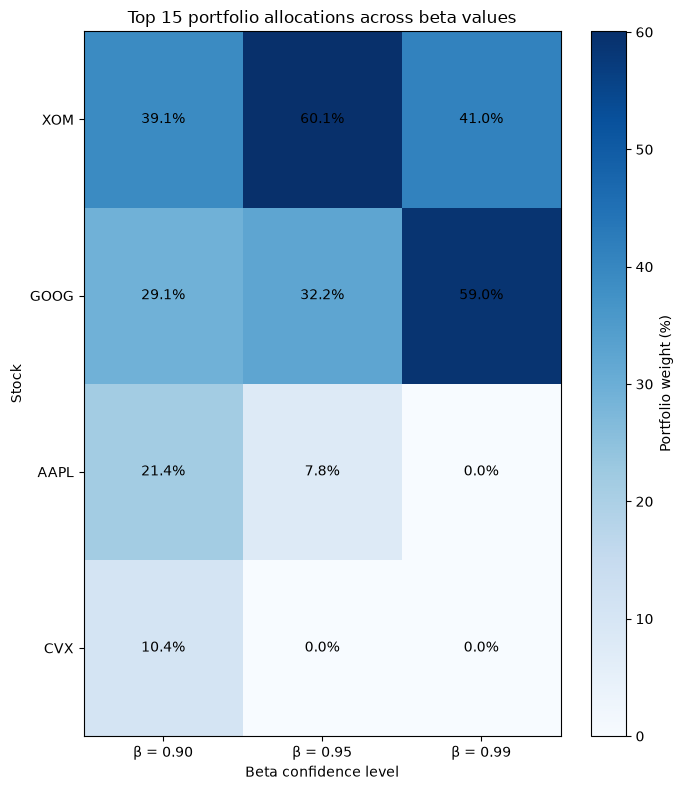

### Part 3 analysis

- **Beta 0.90:** 4 active stocks, largest weight 39.1%, top-two combined weight 68.2%, and CVaR 2.2037%.
- **Beta 0.95:** 3 active stocks, largest weight 60.1%, top-two combined weight 92.2%, and CVaR 2.9135%.
- **Beta 0.99:** 2 active stocks, largest weight 59.0%, top-two combined weight 100.0%, and CVaR 4.6180%.

For this dataset, **beta 0.99** produced the highest concentration index. The graph shows exactly which stock weights changed as the model moved from the worst 10% of days to the worst 5% and then the worst 1%. These results are dataset-specific: a higher beta does not always produce a more concentrated portfolio.

In [43]:
# Re-solve the same portfolio model at beta = 0.90, 0.95, and 0.99.
# Comparing the resulting allocations shows how the definition of the tail
# of the loss distribution changes portfolio construction.
# Reuse the existing beta=0.95 result and solve the two additional models.
# beta is the confidence level: higher beta focuses the model on a smaller, more extreme loss tail.
beta_values = [0.90, 0.95, 0.99]
beta_results = {
    0.90: solve_cvar_portfolio(returns_2025, 0.90, REQUIRED_DAILY_RETURN),
    0.95: baseline_result,
    0.99: solve_cvar_portfolio(returns_2025, 0.99, REQUIRED_DAILY_RETURN)
}

beta_rows = []
allocation_rows = []

for beta_value in beta_values:
    result = beta_results[beta_value]
    weights = result["Weights"]

    # Validate the solution for this beta.
    _, direct_cvar = calculate_fixed_portfolio_cvar(
        result["Portfolio_Returns"],
        beta_value
    )
    assert np.isclose(weights.sum(), 1.0, atol=1e-7)
    assert weights.min() >= -1e-8
    assert result["Mean_Return"] >= REQUIRED_DAILY_RETURN - 1e-8
    assert np.isclose(direct_cvar, result["CVaR"], atol=1e-7)

    beta_rows.append({
        "Beta": beta_value,
        "VaR": result["VaR"],
        "CVaR": result["CVaR"],
        "Mean_Return": result["Mean_Return"],
        "Active_Stocks": int((weights > WEIGHT_TOLERANCE).sum()),
        "Largest_Weight": float(weights.max()),
        "Top_2_Total_Weight": float(np.sort(weights)[-min(2, len(weights)):].sum()),
        # Sum of squared weights: larger values indicate that portfolio weight is concentrated in fewer stocks.
        "Concentration_Index": float(np.square(weights).sum())
    })

    for ticker, weight in zip(returns_2025.columns, weights):
        allocation_rows.append({
            "Beta": beta_value,
            "Ticker": ticker,
            "Weight": weight,
            "Weight_Percent": 100 * weight
        })

beta_summary = pd.DataFrame(beta_rows)
beta_allocations = pd.DataFrame(allocation_rows)

beta_summary_display = beta_summary.copy()
for column in ["VaR", "CVaR", "Mean_Return"]:
    beta_summary_display[column] = (
        beta_summary_display[column].map(lambda value: f"{value:.4%}")
    )
for column in ["Largest_Weight", "Top_2_Total_Weight"]:
    beta_summary_display[column] = (
        beta_summary_display[column].map(lambda value: f"{value:.2%}")
    )
beta_summary_display["Concentration_Index"] = (
    beta_summary_display["Concentration_Index"].map(lambda value: f"{value:.4f}")
)
display(beta_summary_display)

# Reshape the allocations so rows represent stocks and columns represent
# the three beta values.
allocation_pivot = beta_allocations.pivot(
    index="Ticker",
    columns="Beta",
    values="Weight_Percent"
)

# Select the 15 stocks with the largest allocation under at least one beta.
# This keeps the chart readable while showing the most important changes.
top_15_tickers = (
    allocation_pivot
    .max(axis=1)
    .nlargest(15)
    .index
)

heatmap_data = allocation_pivot.loc[top_15_tickers]

# Create a heatmap showing the portfolio weight assigned to each stock.
fig, ax = plt.subplots(figsize=(7, 8))

heatmap = ax.imshow(
    heatmap_data.to_numpy(),
    cmap="Blues",
    aspect="auto"
)

# Label the beta values and stock tickers.
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([
    f"β = {beta_value:.2f}"
    for beta_value in heatmap_data.columns
])

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Display each portfolio weight inside its heatmap cell.
for row_position in range(len(heatmap_data.index)):
    for column_position in range(len(heatmap_data.columns)):
        weight_percent = heatmap_data.iloc[row_position, column_position]

        ax.text(
            column_position,
            row_position,
            f"{weight_percent:.1f}%",
            ha="center",
            va="center",
            color="black"
        )

# Add chart labels and a color scale.
ax.set_title("Top 15 portfolio allocations across beta values")
ax.set_xlabel("Beta confidence level")
ax.set_ylabel("Stock")

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Portfolio weight (%)")

plt.tight_layout()
plt.show()

analysis_lines = []
for row in beta_summary.itertuples(index=False):
    analysis_lines.append(
        f"- **Beta {row.Beta:.2f}:** {row.Active_Stocks} active stocks, "
        f"largest weight {row.Largest_Weight:.1%}, top-two combined weight "
        f"{row.Top_2_Total_Weight:.1%}, and CVaR {row.CVaR:.4%}."
    )

most_concentrated = beta_summary.loc[
    beta_summary["Concentration_Index"].idxmax()
]

display(Markdown(
    "### Part 3 analysis\n\n"
    + "\n".join(analysis_lines)
    + f"\n\nFor this dataset, **beta {most_concentrated['Beta']:.2f}** produced "
      "the highest concentration index. The graph shows exactly which stock "
      "weights changed as the model moved from the worst 10% of days to the "
      "worst 5% and then the worst 1%. These results are dataset-specific: a "
      "higher beta does not always produce a more concentrated portfolio."
))


## Part 4: Worst-month CVaR

Use 2025 data to minimize the maximum monthly CVaR rather than the CVaR of the entire year. Compare the resulting risk and allocation with Part 2.

Worst-month CVaR. The Part 2 objective pools all available daily return observations into one CVaR number. Part 4 instead needs a separate CVaR expression for each calendar month present in the data and a portfolio that minimizes the largest monthly CVaR across the calendar months present in the data. This is still a linear program: introduce one alpha (VaR cutoff) and one CVaR expression per month, plus a scalar t that is forced (vvia one inequality constraint for each calendar month present in the data) to be at least as large as every month's CVaR, then minimize t. Everything else (budget, long-only, required-return constraints) stays identical to Part 2.

,Metric,Part_2_Average_CVaR_Portfolio,Part_4_Worst_Month_Portfolio
0,Pooled annual CVaR (Part 2 objective),2.9135%,3.1395%
1,Worst single month's CVaR,5.8816%,4.6469%
2,Average monthly CVaR,2.2322%,2.5462%
3,Mean daily return,0.1195%,0.1672%


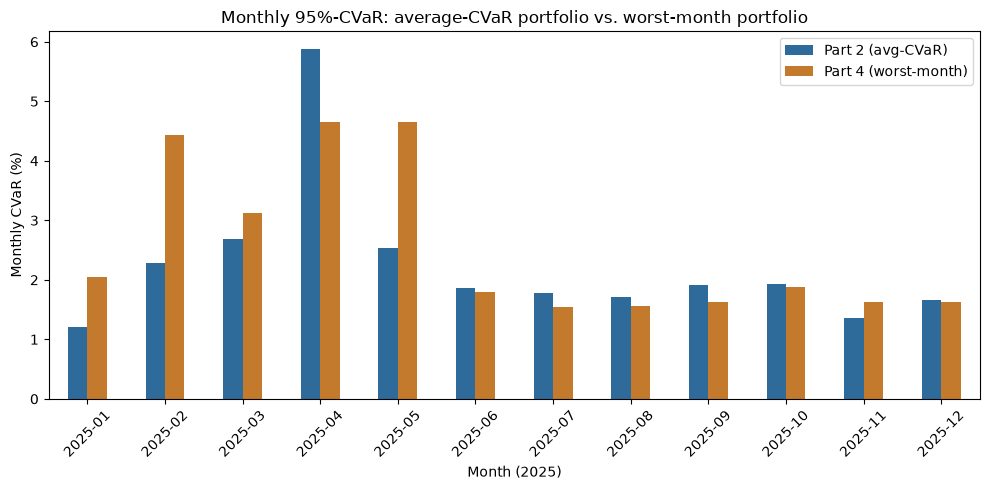


### Part 4 - Risk Comparison with Part 2

Minimizing the worst month's CVaR lowered the single worst month's CVaR from
**5.8816%** (Part 2 portfolio) to
**4.6469%** (Part 4 portfolio), a
**21.0% reduction** in the worst-case monthly tail loss.
This came at the cost of the pooled annual CVaR moving from
**2.9135%** to **3.1395%**
(a 7.8% increase
 in average tail risk). This is the expected trade-off: a min-max objective
trades away some average-case efficiency to guarantee protection against the
single worst month, whereas Part 2's objective is only concerned with the
pooled average across all days.


In [44]:
# Part 4 changes the optimization objective: instead of minimizing one pooled CVaR across all days, minimize the largest monthly CVaR.
# Each month receives its own VaR threshold, while the portfolio weights remain common across the entire year.

'''
    Long-only portfolio that minimizes the LARGEST monthly beta-CVaR
    across the calendar months present in return_data.

    Unlike solve_cvar_portfolio (Part 2), which pools every day into one
    CVaR number, this model gives each month its own VaR cutoff (alpha_m)
    and its own CVaR expression, then minimizes the worst of those monthly CVaR values.
    '''

def solve_worst_month_cvar_portfolio(return_data, beta, required_return):
    if not 0.0 < beta < 1.0:
        raise ValueError("beta must be strictly between 0 and 1.")

    Y = return_data.to_numpy(dtype=float)
    q, n = Y.shape
    mean_stock_returns = Y.mean(axis=0)

    if mean_stock_returns.max() < required_return:
        raise ValueError("The required return is infeasible for these stocks.")

    # Group trading days by calendar month (e.g. 2025-01, 2025-02, ...).
    month_labels = return_data.index.to_period("M")
    unique_months = month_labels.unique().sort_values()
    day_rows_by_month = {
        month: np.where(month_labels == month)[0]
        for month in unique_months
    }

    model = gp.Model(f"worst_month_cvar_beta_{beta:.2f}")
    model.Params.OutputFlag = 0

    # Decision variables
    weights = model.addMVar(n, lb=0.0, name="weight")
    excess_loss = model.addMVar(q, lb=0.0, name="excess_loss")

    # One VaR cutoff per month (free in sign, same as Part 2's alpha).
    monthly_alpha = model.addVars(
        len(unique_months), lb=-GRB.INFINITY, name="monthly_alpha"
    )
    # t = the largest of the monthly CVaR values; this is what we minimize.
    worst_month_cvar = model.addVar(lb=-GRB.INFINITY, name="worst_month_cvar")

    model.setObjective(worst_month_cvar, GRB.MINIMIZE)

    # Same portfolio-level constraints as in Part 2.
    model.addConstr(weights.sum() == 1.0, name="fully_invested")
    model.addConstr(
        mean_stock_returns @ weights >= required_return,
        name="required_mean_return"
    )

    # Build one excess-loss block and one CVaR upper-bound constraint per calendar month.
    for month_position, month in enumerate(unique_months):
        day_rows = day_rows_by_month[month]
        q_month = len(day_rows)

        # Daily excess-loss constraints for the days in this month only,
        # referencing that month's own alpha.
        model.addConstr(
            excess_loss[day_rows]
            >= -(Y[day_rows] @ weights) - monthly_alpha[month_position],
            name=f"daily_excess_loss_{month}"
        )

        # Force 't' to be at least this month's CVaR.
        model.addConstr(
            worst_month_cvar
            >= monthly_alpha[month_position]
            + excess_loss[day_rows].sum() / ((1.0 - beta) * q_month),
            name=f"month_cvar_bound_{month}"
        )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"Gurobi did not find an optimal solution; status={model.Status}."
        )

    optimized_weights = weights.X.copy()
    portfolio_returns = Y @ optimized_weights

    # Independently recompute every month's realized CVaR with the fixed weights

    monthly_cvar_check = {}
    for month in unique_months:
        day_rows = day_rows_by_month[month]
        _, month_cvar = calculate_fixed_portfolio_cvar(
            portfolio_returns[day_rows], beta
        )
        monthly_cvar_check[str(month)] = month_cvar

    return {
        "Beta": beta,
        "Weights": optimized_weights,
        "Worst_Month_CVaR": float(model.ObjVal),
        "Mean_Return": float(mean_stock_returns @ optimized_weights),
        "Portfolio_Returns": portfolio_returns,
        "Monthly_CVaR": monthly_cvar_check,
        "Days": q,
        "Stocks": n
    }

'''Realized monthly VaR/CVaR of a FIXED weight vector, month by month.'''

def get_monthly_cvar_series(weights, return_data, beta):
    '''Realized monthly VaR/CVaR of a FIXED weight vector, month by month.'''
    portfolio_returns = return_data.to_numpy(dtype=float) @ weights
    month_labels = return_data.index.to_period("M")
    rows = []
    for month in month_labels.unique().sort_values():
        mask = (month_labels == month)  # already a NumPy bool array — no .to_numpy() needed
        month_var, month_cvar = calculate_fixed_portfolio_cvar(
            portfolio_returns[mask], beta
        )
        rows.append({"Month": str(month), "VaR": month_var, "CVaR": month_cvar})
    return pd.DataFrame(rows)


# Solve the Part 4 model on 2025 data
worst_month_result = solve_worst_month_cvar_portfolio(
    return_data=returns_2025,
    beta=BETA_BASELINE,
    required_return=REQUIRED_DAILY_RETURN
)

# Sanity checks

worst_month_weights = worst_month_result["Weights"]
assert np.isclose(worst_month_weights.sum(), 1.0, atol=1e-7)
assert worst_month_weights.min() >= -1e-8
assert worst_month_result["Mean_Return"] >= REQUIRED_DAILY_RETURN - 1e-8

# Pooled annual CVaR for the Part 4 portfolio, computed the same way as baseline_result["CVaR"]
worst_month_annual_var, worst_month_annual_cvar = calculate_fixed_portfolio_cvar(
    worst_month_result["Portfolio_Returns"], BETA_BASELINE
)

# Monthly CVaR series for both portfolios, evaluated on the same 2025 data.
baseline_monthly_cvar = get_monthly_cvar_series(
    baseline_weights, returns_2025, BETA_BASELINE
)
worst_month_monthly_cvar = get_monthly_cvar_series(
    worst_month_weights, returns_2025, BETA_BASELINE
)

part4_comparison = pd.DataFrame({
    "Metric": [
        "Pooled annual CVaR (Part 2 objective)",
        "Worst single month's CVaR",
        "Average monthly CVaR",
        "Mean daily return"
    ],
    "Part_2_Average_CVaR_Portfolio": [
        baseline_result["CVaR"],
        baseline_monthly_cvar["CVaR"].max(),
        baseline_monthly_cvar["CVaR"].mean(),
        baseline_result["Mean_Return"]
    ],
    "Part_4_Worst_Month_Portfolio": [
        worst_month_annual_cvar,
        worst_month_result["Worst_Month_CVaR"],
        worst_month_monthly_cvar["CVaR"].mean(),
        worst_month_result["Mean_Return"]
    ]
})

part4_comparison_display = part4_comparison.copy()
for column in ["Part_2_Average_CVaR_Portfolio", "Part_4_Worst_Month_Portfolio"]:
    part4_comparison_display[column] = part4_comparison_display[column].map(
        lambda value: f"{value:.4%}"
    )
display(part4_comparison_display)

# Plot: monthly CVaR side by side for both portfolios.
monthly_plot = pd.DataFrame({
    "Part 2 (avg-CVaR)": baseline_monthly_cvar.set_index("Month")["CVaR"],
    "Part 4 (worst-month)": worst_month_monthly_cvar.set_index("Month")["CVaR"]
}) * 100
ax = monthly_plot.plot.bar(figsize=(10, 5), color=["#2F6B9A", "#C47A2C"])
ax.set_title("Monthly 95%-CVaR: average-CVaR portfolio vs. worst-month portfolio")
ax.set_ylabel("Monthly CVaR (%)")
ax.set_xlabel("Month (2025)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

worst_month_reduction = (
    1.0 - worst_month_result["Worst_Month_CVaR"] / baseline_monthly_cvar["CVaR"].max()
)
annual_cost = worst_month_annual_cvar / baseline_result["CVaR"] - 1.0

display(Markdown(f'''
### Part 4 - Risk Comparison with Part 2

Minimizing the worst month's CVaR lowered the single worst month's CVaR from
**{baseline_monthly_cvar["CVaR"].max():.4%}** (Part 2 portfolio) to
**{worst_month_result["Worst_Month_CVaR"]:.4%}** (Part 4 portfolio), a
**{worst_month_reduction:.1%} reduction** in the worst-case monthly tail loss.
This came at the cost of the pooled annual CVaR moving from
**{baseline_result["CVaR"]:.4%}** to **{worst_month_annual_cvar:.4%}**
({"a " + f"{abs(annual_cost):.1%} increase" if annual_cost > 0 else f"a {abs(annual_cost):.1%} decrease"}
 in average tail risk). This is the expected trade-off: a min-max objective
trades away some average-case efficiency to guarantee protection against the
single worst month, whereas Part 2's objective is only concerned with the
pooled average across all days.
'''))

In [45]:
# Compare the stock-level allocations from Part 2 and Part 4.
part4_allocation_comparison = pd.DataFrame({
    "Ticker": returns_2025.columns,
    "Part_2_Weight": baseline_weights,
    "Part_4_Weight": worst_month_weights
})

part4_allocation_comparison["Absolute_Change"] = (
    part4_allocation_comparison["Part_4_Weight"]
    - part4_allocation_comparison["Part_2_Weight"]
).abs()

# Sorting by absolute change highlights the stocks whose portfolio weights were most affected by the change in risk objective.

part4_allocation_comparison = (
    part4_allocation_comparison
    .sort_values("Absolute_Change", ascending=False)
)

display(part4_allocation_comparison.head(10))

,Ticker,Part_2_Weight,Part_4_Weight,Absolute_Change
3,GOOG,0.321682,0.635507,0.313825
2,XOM,0.600591,0.364493,0.236098
0,AAPL,0.077727,0.000000,0.077727
1,CVX,0.000000,0.000000,0.000000


In [46]:
# Dynamic Part 4 comparison and interpretation

part2_worst_month_cvar = baseline_monthly_cvar["CVaR"].max()
part4_worst_month_cvar = worst_month_monthly_cvar["CVaR"].max()

worst_month = worst_month_monthly_cvar.loc[
    worst_month_monthly_cvar["CVaR"].idxmax(), "Month"
]

worst_month_reduction = (
    1 - part4_worst_month_cvar / part2_worst_month_cvar
)

part2_pooled_cvar = baseline_result["CVaR"]
part4_pooled_cvar = worst_month_annual_cvar

pooled_cvar_change = (
    part4_pooled_cvar / part2_pooled_cvar - 1
)

part2_avg_monthly_cvar = baseline_monthly_cvar["CVaR"].mean()
part4_avg_monthly_cvar = worst_month_monthly_cvar["CVaR"].mean()

largest_allocation_changes = part4_allocation_comparison.head(3)

allocation_summary = "; ".join(
    f"{row.Ticker}: {row.Part_2_Weight:.2%} → {row.Part_4_Weight:.2%}"
    for _, row in largest_allocation_changes.iterrows()
)

worst_month_cvar_change = (
    part4_worst_month_cvar / part2_worst_month_cvar - 1
)

display(Markdown(f"""
### Part 4 - Portfolio Allocation Comparison

The maximum monthly CVaR is **{part2_worst_month_cvar:.4%}**
under Part 2 and **{part4_worst_month_cvar:.4%}** under Part 4,
representing a **{worst_month_cvar_change:.1%}** change.

The trade-off is that the pooled CVaR changes from
**{part2_pooled_cvar:.4%}** under Part 2 to
**{part4_pooled_cvar:.4%}** under Part 4, a change of
**{pooled_cvar_change:.1%}**.

The average monthly CVaR changes from
**{part2_avg_monthly_cvar:.4%}** under Part 2 to
**{part4_avg_monthly_cvar:.4%}** under Part 4.

The largest allocation changes are:
**{allocation_summary}**.

Thus, Part 4 shifts the optimization objective toward controlling the
worst monthly tail-risk outcome rather than optimizing the pooled
CVaR across all daily observations.
"""))


### Part 4 - Portfolio Allocation Comparison

The maximum monthly CVaR is **5.8816%**
under Part 2 and **4.6469%** under Part 4,
representing a **-21.0%** change.

The trade-off is that the pooled CVaR changes from
**2.9135%** under Part 2 to
**3.1395%** under Part 4, a change of
**7.8%**.

The average monthly CVaR changes from
**2.2322%** under Part 2 to
**2.5462%** under Part 4.

The largest allocation changes are:
**GOOG: 32.17% → 63.55%; XOM: 60.06% → 36.45%; AAPL: 7.77% → 0.00%**.

Thus, Part 4 shifts the optimization objective toward controlling the
worst monthly tail-risk outcome rather than optimizing the pooled
CVaR across all daily observations.


## Part 5: Monthly reoptimization

For each 2026 month, optimize a new portfolio using the preceding one-year window. Evaluate the realized monthly CVaR and report its average, variation, minimum, and maximum. Compare the sequence with the fixed Part 2 portfolio and discuss whether the improvement justifies turnover and transaction costs.

Monthly reoptimization in 2026. Each 2026 month's portfolio uses the trailing 12 months of daily returns. Conveniently, returns_2025 and returns_2026 together already span Jan 2025 – Sep 14 2026, so no new downloads are needed — just concatenate them and slice a rolling window for each target month, call the existing solve_cvar_portfolio(), and evaluate the resulting weights out-of-sample on that month's own realized returns.

,Month,Training_Start,Training_End,Trading_Days_In_Month,Realized_VaR,Realized_CVaR,Realized_Mean_Return,Fixed_Part2_CVaR,CVaR_Difference
0,2026-01,2025-01-01,2025-12-31,20,0.8472%,2.4882%,0.6013%,2.4882%,0.0000%
1,2026-02,2025-02-01,2026-01-31,19,2.4215%,2.4215%,0.1438%,2.3788%,0.0427%
2,2026-03,2025-03-01,2026-02-28,22,1.1747%,1.2500%,-0.0052%,1.2226%,0.0275%
3,2026-04,2025-04-01,2026-03-31,21,0.6937%,0.7749%,0.6643%,2.1533%,-1.3783%
4,2026-05,2025-05-01,2026-04-30,20,1.2048%,1.4235%,-0.0253%,2.2314%,-0.8079%
5,2026-06,2025-06-01,2026-05-31,21,1.6917%,1.7418%,-0.3397%,1.5349%,0.2070%
6,2026-07,2025-07-01,2026-06-30,22,0.9962%,1.9650%,0.4159%,1.6819%,0.2831%
7,2026-08,2025-08-01,2026-07-31,21,1.0768%,2.0564%,0.0599%,2.1347%,-0.0783%
8,2026-09,2025-09-01,2026-08-31,9,1.6489%,1.6489%,0.3731%,1.5466%,0.1023%


,Statistic,Value
0,Average monthly CVaR,1.7523%
1,Std. dev. of monthly CVaR,0.5538%
2,Minimum monthly CVaR,0.7749%
3,Maximum monthly CVaR,2.4882%
4,Pooled 2026 CVaR (monthly reoptimization),1.8896%
5,Pooled 2026 CVaR (fixed Part 2 portfolio),1.9894%


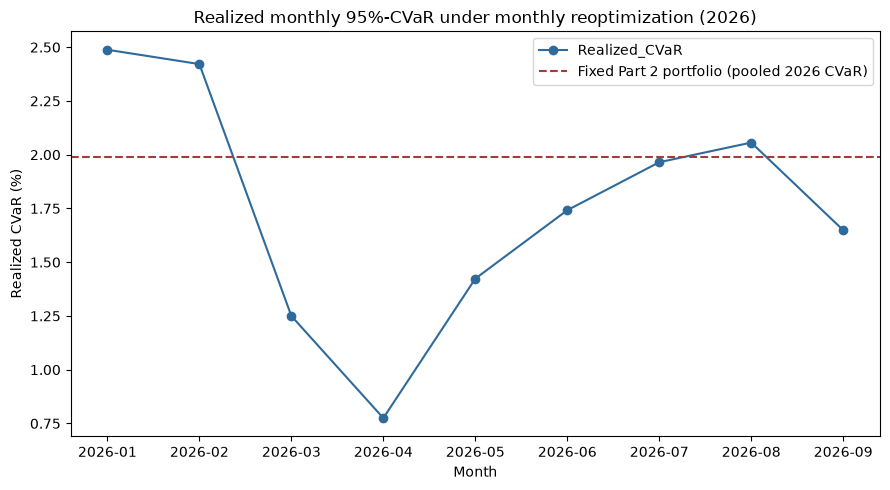


### Part 5 analysis

Monthly reoptimization produced a pooled 2026 CVaR of **1.8896%**,
versus **1.9894%** for the Part 2 portfolio held fixed throughout
the year, representing a **5.0% lower CVaR**.

Across the available months, realized monthly CVaR ranged from
**0.7749%** to
**2.4882%**, with a standard deviation
of **0.5538%**.

Monthly reoptimization produced a lower realized CVaR than the fixed
Part 2 portfolio in **3** of the
**9** observed months, and a higher realized CVaR in
**5** months.

The CVaR comparison indicates how the monthly reoptimization strategy
performed relative to the fixed portfolio out of sample. Whether the
difference justifies monthly rebalancing cannot be determined from CVaR
alone because transaction and implementation costs are not included in
this analysis.


In [47]:
# Build one continuous daily-return series spanning Jan 2025 - Sep 14 2026
# by reusing the already-validated returns_2025 and returns_2026 matrices
# (both are aligned on the same eligible_tickers columns).

returns_all = pd.concat([returns_2025, returns_2026]).sort_index()

if returns_all.index.duplicated().any():
    raise ValueError("Combined 2025-2026 return series contains duplicate dates.")

# Target months: every 2026 calendar month for which we actually have
# realized return data (Jan through the partial September sample).
target_months = sorted(returns_2026.index.to_period("M").unique())

monthly_portfolios = []
monthly_weight_rows = []
realized_return_blocks = []

for target_month in target_months:
    # Trailing 12-month training window, ending the day before this month
    # starts. Example: target month 2026-02 -> training window
    # 2025-02-01 through 2026-01-31.
    training_start = target_month.start_time - pd.DateOffset(years=1)
    training_end = target_month.start_time - pd.Timedelta(days=1)

    training_mask = (
        (returns_all.index >= training_start) & (returns_all.index <= training_end)
    )
    training_returns = returns_all.loc[training_mask]

    if training_returns.empty:
        raise ValueError(f"No training data available for target month {target_month}.")

    # Re-optimize the CVaR portfolio using only data available before
    # this month began (same beta and required return as Part 2).
    month_result = solve_cvar_portfolio(
        return_data=training_returns,
        beta=BETA_BASELINE,
        required_return=REQUIRED_DAILY_RETURN
    )
    month_weights = month_result["Weights"]

    # Evaluate those FIXED weights on the target month's own realized
    # returns -- this is genuinely out-of-sample for that month.
    target_mask = returns_all.index.to_period("M") == target_month
    target_returns = returns_all.loc[target_mask]
    realized_returns = target_returns.to_numpy(dtype=float) @ month_weights
    realized_var, realized_cvar = calculate_fixed_portfolio_cvar(
        realized_returns, BETA_BASELINE
    )

    monthly_portfolios.append({
        "Month": str(target_month),
        "Training_Start": training_start.strftime("%Y-%m-%d"),
        "Training_End": training_end.strftime("%Y-%m-%d"),
        "Trading_Days_In_Month": len(target_returns),
        "Realized_VaR": realized_var,
        "Realized_CVaR": realized_cvar,
        "Realized_Mean_Return": float(realized_returns.mean())
    })
    monthly_weight_rows.append(month_weights)
    realized_return_blocks.append(realized_returns)

monthly_summary = pd.DataFrame(monthly_portfolios)

# Weight matrix: rows = 2026 target months, columns = stocks.
monthly_weights_matrix = pd.DataFrame(
    monthly_weight_rows,
    index=monthly_summary["Month"],
    columns=returns_2025.columns
)

# Stitch every month's realized daily returns into one series so we can
# compute a single pooled CVaR for the whole reoptimization strategy,
# directly comparable to cvar_2026 (Part 2's fixed portfolio, out-of-sample)

reopt_returns_2026 = np.concatenate(realized_return_blocks)
reopt_var_2026, reopt_cvar_2026 = calculate_fixed_portfolio_cvar(
    reopt_returns_2026, BETA_BASELINE
)

# Calculate the fixed Part 2 portfolio's CVaR separately for each 2026 month
# so we can make a month-to-month comparison on the same basis.

fixed_monthly_cvar = []

for target_month in target_months:
    month_mask = returns_2026.index.to_period("M") == target_month

    fixed_month_returns = (
        returns_2026.loc[month_mask].to_numpy(dtype=float)
        @ baseline_weights
    )

    _, month_cvar = calculate_fixed_portfolio_cvar(
        fixed_month_returns,
        BETA_BASELINE
    )

    fixed_monthly_cvar.append(month_cvar)

monthly_summary["Fixed_Part2_CVaR"] = fixed_monthly_cvar

monthly_summary["CVaR_Difference"] = (
    monthly_summary["Realized_CVaR"]
    - monthly_summary["Fixed_Part2_CVaR"]
)

monthly_summary_display = monthly_summary.copy()
for column in ["Realized_VaR", "Realized_CVaR", "Fixed_Part2_CVaR", "CVaR_Difference", "Realized_Mean_Return"]:
    monthly_summary_display[column] = monthly_summary_display[column].map(
        lambda value: f"{value:.4%}"
    )
display(monthly_summary_display)

part5_stats = pd.DataFrame({
    "Statistic": [
        "Average monthly CVaR",
        "Std. dev. of monthly CVaR",
        "Minimum monthly CVaR",
        "Maximum monthly CVaR",
        "Pooled 2026 CVaR (monthly reoptimization)",
        "Pooled 2026 CVaR (fixed Part 2 portfolio)"
    ],
    "Value": [
        monthly_summary["Realized_CVaR"].mean(),
        monthly_summary["Realized_CVaR"].std(),
        monthly_summary["Realized_CVaR"].min(),
        monthly_summary["Realized_CVaR"].max(),
        reopt_cvar_2026,
        cvar_2026  # computed earlier in the notebook, Part 2 Step 7
    ]
})
part5_stats_display = part5_stats.copy()
part5_stats_display["Value"] = part5_stats_display["Value"].map(lambda v: f"{v:.4%}")
display(part5_stats_display)

# Plot the monthly realized CVaR across 2026.
ax = monthly_summary.set_index("Month")["Realized_CVaR"].mul(100).plot(
    kind="line", marker="o", figsize=(9, 5), color="#2F6B9A"
)
ax.axhline(
    cvar_2026 * 100, color="#A23B3B", linestyle="--",
    label="Fixed Part 2 portfolio (pooled 2026 CVaR)"
)
ax.set_title("Realized monthly 95%-CVaR under monthly reoptimization (2026)")
ax.set_ylabel("Realized CVaR (%)")
ax.set_xlabel("Month")
ax.legend()
plt.tight_layout()
plt.show()

reopt_vs_fixed = 1.0 - reopt_cvar_2026 / cvar_2026
direction = "lower" if reopt_vs_fixed >= 0 else "higher"

months_reopt_better = (
    monthly_summary["CVaR_Difference"] < 0
).sum()

months_reopt_worse = (
    monthly_summary["CVaR_Difference"] > 0
).sum()


display(Markdown(f'''
### Part 5 analysis

Monthly reoptimization produced a pooled 2026 CVaR of **{reopt_cvar_2026:.4%}**,
versus **{cvar_2026:.4%}** for the Part 2 portfolio held fixed throughout
the year, representing a **{abs(reopt_vs_fixed):.1%} {direction} CVaR**.

Across the available months, realized monthly CVaR ranged from
**{monthly_summary["Realized_CVaR"].min():.4%}** to
**{monthly_summary["Realized_CVaR"].max():.4%}**, with a standard deviation
of **{monthly_summary["Realized_CVaR"].std():.4%}**.

Monthly reoptimization produced a lower realized CVaR than the fixed
Part 2 portfolio in **{months_reopt_better}** of the
**{len(monthly_summary)}** observed months, and a higher realized CVaR in
**{months_reopt_worse}** months.

The CVaR comparison indicates how the monthly reoptimization strategy
performed relative to the fixed portfolio out of sample. Whether the
difference justifies monthly rebalancing cannot be determined from CVaR
alone because transaction and implementation costs are not included in
this analysis.
'''))

## Part 6: Stability

Check whether every stock's weight changes by no more than 0.02 between consecutive monthly portfolios. If not, explain that stability could be enforced with

$$x_{t,j}-x_{t-1,j}\le0.02$$

and

$$x_{t-1,j}-x_{t,j}\le0.02.$$

Stability check: Take the sequence of monthly weight vectors from Part 5 and check whether any single stock's weight moves by more than 0.02 between consecutive months. If it's unstable we don't re-solve anything and explain how we would bolt on the linking constraints.

,Month_Transition,Largest_Single_Stock_Change
0,2026-02,1.59%
1,2026-03,27.26%
2,2026-04,0.80%
3,2026-05,34.68%
4,2026-06,4.23%
5,2026-07,13.99%
6,2026-08,7.81%
7,2026-09,24.36%


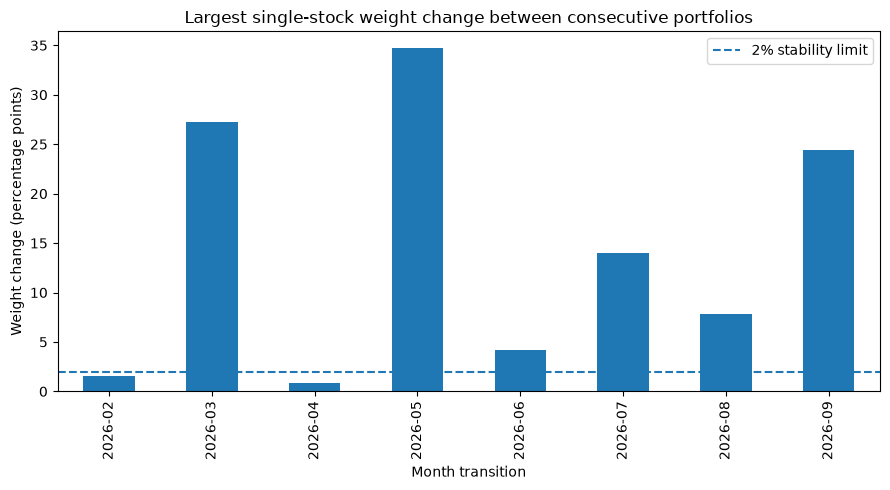


### Part 6 analysis


The sequence of monthly portfolios from Part 5 is **not stable**:
**6 of 8**
month-to-month transitions contain at least one stock whose weight
changed by more than **2%**.

There are **19** individual (month, stock) pairs that
violate the stability limit, with the largest single-stock change being
**34.68%**.

Per the assignment, a new optimization model does not need to be solved.
Instead, stability could be enforced by adding, to each month's CVaR
optimization, the following linear constraints for every stock j:

$$
x_{t,j} - x_{t-1,j} \leq 0.02
$$

$$
x_{t-1,j} - x_{t,j} \leq 0.02
$$

for each month $t$ after the first month. Here, $x_{t-1}$ represents
the previously optimized portfolio and is treated as fixed when solving
for month $t$.

Together, these constraints enforce

$$
|x_{t,j} - x_{t-1,j}| \leq 0.02.
$$

Because these are linear constraints on the existing portfolio-weight
variables, the CVaR optimization remains a linear program. The trade-off
is that imposing the stability constraint may increase the month's
**optimized CVaR** relative to the unconstrained optimum because the
optimizer can no longer make a weight change larger than the allowed
limit.



In [48]:
# Month-over-month weight changes for every stock.
# Row i represents the change from the previous month's portfolio
# to the current month's portfolio.
weight_changes = monthly_weights_matrix.diff().dropna()

# Stability requirement from the assignment: no stock's weight
# may change by more than 2 percentage points between consecutive months.
STABILITY_LIMIT = 0.02

# Largest single-stock weight change at each month-to-month transition.
max_change_per_transition = weight_changes.abs().max(axis=1)

# Count the number of month-to-month transitions that contain
# at least one stock whose weight exceeds the stability limit.
violating_transitions = (
    max_change_per_transition > STABILITY_LIMIT + 1e-8
).sum()

# Identify every (transition, stock) pair that violates the limit.
violations = (
    weight_changes.abs()
    .stack()
    .loc[lambda s: s > STABILITY_LIMIT + 1e-8]
    .rename("Weight_Change")
    .reset_index()
    .rename(columns={
        "level_0": "Month",
        "level_1": "Ticker"
    })
    .sort_values("Weight_Change", ascending=False)
)

is_stable = violations.empty

# Summary of the largest weight change for each transition.
stability_summary = pd.DataFrame({
    "Month_Transition": max_change_per_transition.index,
    "Largest_Single_Stock_Change": max_change_per_transition.values
})

stability_summary_display = stability_summary.copy()

stability_summary_display["Largest_Single_Stock_Change"] = (
    stability_summary_display["Largest_Single_Stock_Change"]
    .map(lambda v: f"{v:.2%}")
)

display(stability_summary_display)

# Plot the largest stock-level weight change for each transition.
ax = max_change_per_transition.mul(100).plot.bar(figsize=(9, 5))

ax.axhline(
    STABILITY_LIMIT * 100,
    linestyle="--",
    label=f"{STABILITY_LIMIT:.0%} stability limit"
)

ax.set_title(
    "Largest single-stock weight change between consecutive portfolios"
)
ax.set_ylabel("Weight change (percentage points)")
ax.set_xlabel("Month transition")
ax.legend()

plt.tight_layout()
plt.show()

# Generate a dynamic interpretation of the stability results.
if is_stable:

    stability_verdict = f"""
The sequence of monthly portfolios from Part 5 is **stable**:
all **{len(max_change_per_transition)}** observed month-to-month
transitions satisfy the **{STABILITY_LIMIT:.0%}** maximum weight-change
requirement. The largest single-stock weight change observed was
**{max_change_per_transition.max():.2%}**.

Because the existing monthly portfolio sequence already satisfies the
stability requirement, no additional stability constraints are needed
for these portfolios.
"""

else:

    largest_change = violations["Weight_Change"].max()

    stability_verdict = f"""
The sequence of monthly portfolios from Part 5 is **not stable**:
**{violating_transitions} of {len(max_change_per_transition)}**
month-to-month transitions contain at least one stock whose weight
changed by more than **{STABILITY_LIMIT:.0%}**.

There are **{len(violations)}** individual (month, stock) pairs that
violate the stability limit, with the largest single-stock change being
**{largest_change:.2%}**.

Per the assignment, a new optimization model does not need to be solved.
Instead, stability could be enforced by adding, to each month's CVaR
optimization, the following linear constraints for every stock j:

$$
x_{{t,j}} - x_{{t-1,j}} \\leq {STABILITY_LIMIT}
$$

$$
x_{{t-1,j}} - x_{{t,j}} \\leq {STABILITY_LIMIT}
$$

for each month $t$ after the first month. Here, $x_{{t-1}}$ represents
the previously optimized portfolio and is treated as fixed when solving
for month $t$.

Together, these constraints enforce

$$
|x_{{t,j}} - x_{{t-1,j}}| \\leq {STABILITY_LIMIT}.
$$

Because these are linear constraints on the existing portfolio-weight
variables, the CVaR optimization remains a linear program. The trade-off
is that imposing the stability constraint may increase the month's
**optimized CVaR** relative to the unconstrained optimum because the
optimizer can no longer make a weight change larger than the allowed
limit.
"""

display(Markdown(f"""
### Part 6 analysis

{stability_verdict}
"""))